#  06. 7-Day Daily AQI Forecasting — Optimal Non-Redundant Pipeline

This notebook implements the **recovered 21-feature optimal 7-day forecasting pipeline** ($y = AQI_{t+7}$) using **LightGBM Early-Stopping Optuna Bayesian Tuning** over 5-fold TimeSeriesSplit cross-validation.

### Key Architectural Fixes:
1. **Multicollinearity Elimination**: Removed duplicate simple moving averages and noisy high-order derivatives that caused variance inflation.
2. **Early Stopping**: Prevents tree overfitting using 25-round early stopping on internal TimeSeriesSplit validation folds.
3. **Optimized Predictor Vector**: 21 non-redundant causal features ($t \le 0$).
4. **Performance**: Achieves **$R^2 = 0.2481$**, **$	ext{MAE} = 36.79$** on the held-out test split ($2024–2026$).


In [1]:
import os
import time
import json
import joblib
import optuna
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score
from lightgbm import LGBMRegressor, early_stopping
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)
print("✓ Libraries & Early-Stopping Optuna engine loaded successfully.")

✓ Libraries & Early-Stopping Optuna engine loaded successfully.


In [2]:
paths = [
    '../data/processed/nehru_nagar_with_aqi.csv',
    'data/processed/nehru_nagar_with_aqi.csv'
]
df = None
for path in paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'Check: Loaded processed dataset from {path}')
        break

if df is None:
    raise FileNotFoundError('Processed dataset nehru_nagar_with_aqi.csv not found.')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 7-Day Ahead Future Target
df['target_aqi_7d'] = df['AQI'].shift(-7)

print(f'Original Records: {len(df)}')
print(f'Date Range      : {df["Date"].min().strftime("%Y-%m-%d")} to {df["Date"].max().strftime("%Y-%m-%d")}')

Check: Loaded processed dataset from ../data/processed/nehru_nagar_with_aqi.csv
Original Records: 3976
Date Range      : 2015-01-01 to 2026-06-23


In [3]:
# 1. Multi-Scale Lags
for l in [1, 2, 7, 14, 21, 28, 30]:
    df[f'aqi_lag_{l}'] = df['AQI'].shift(l - 1)

df['pm25_lag_1'] = df['pm2.5']
df['pm10_lag_1'] = df['pm10']
df['co_lag_1']   = df['co']
df['no2_lag_1']  = df['NO2']
df['o3_lag_1']   = df['O3']

# 2. Exponentially Weighted Moving Averages (EMA)
for span in [7, 14, 30]:
    df[f'aqi_ema_{span}'] = df['AQI'].shift(1).ewm(span=span, adjust=False).mean()

# 3. Velocity & Slope
df['aqi_velocity_3d'] = df['aqi_lag_1'] - df['aqi_lag_7']

def calc_slope(series):
    if len(series) < 2 or np.isnan(series).any():
        return np.nan
    return np.polyfit(np.arange(len(series)), series, 1)[0]

df['aqi_slope_7d'] = df['AQI'].shift(1).rolling(window=7).apply(calc_slope, raw=True)

# 4. Chemical Ratios & Domain Indicators
df['pm25_pm10_ratio']    = df['pm2.5'] / (df['pm10'] + 1e-5)
df['o3_no2_interaction'] = df['O3'] * df['NO2']

day_of_year = df['Date'].dt.dayofyear
df['is_crop_burning_season'] = day_of_year.between(293, 319).astype(int)

severe_mask = (df['AQI'].shift(1) > 300).astype(int)
df['consecutive_severe_days'] = severe_mask.groupby((severe_mask != severe_mask.shift()).cumsum()).cumsum()

df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12.0)

# Optimal 21 Non-Redundant Causal Predictors
selected_features = [
    'aqi_ema_14', 'aqi_ema_7', 'aqi_ema_30', 'aqi_lag_1', 'pm25_lag_1', 'aqi_lag_7',
    'aqi_lag_14', 'aqi_lag_21', 'aqi_lag_28', 'Month_cos', 'co_lag_1', 'consecutive_severe_days',
    'pm25_pm10_ratio', 'pm10_lag_1', 'is_crop_burning_season', 'no2_lag_1', 'o3_no2_interaction',
    'aqi_slope_7d', 'aqi_velocity_3d', 'o3_lag_1', 'season_Monsoon'
]

df_clean = df.dropna(subset=selected_features + ['target_aqi_7d']).reset_index(drop=True)

print(f'✓ Optimal Causal Feature Matrix Constructed ({len(selected_features)} features). Clean Rows: {len(df_clean)}')

✓ Optimal Causal Feature Matrix Constructed (21 features). Clean Rows: 3942


In [4]:
split_idx = int(len(df_clean) * 0.8)
df_train = df_clean.iloc[:split_idx].copy()
df_test = df_clean.iloc[split_idx:].copy()

scale_cols = [c for c in selected_features if not c.startswith(('is_', 'Month_', 'season_'))]

scaler = StandardScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
df_test[scale_cols] = scaler.transform(df_test[scale_cols])

X_train = df_train[selected_features]
y_train = df_train['target_aqi_7d']
X_test = df_test[selected_features]
y_test = df_test['target_aqi_7d']

print(f'Train Partition: {X_train.shape[0]} rows ({df_train["Date"].min().strftime("%Y-%m-%d")} to {df_train["Date"].max().strftime("%Y-%m-%d")})')
print(f'Test Partition : {X_test.shape[0]} rows ({df_test["Date"].min().strftime("%Y-%m-%d")} to {df_test["Date"].max().strftime("%Y-%m-%d")})')
print('✓ Chronological Split and StandardScaler fit-on-train applied successfully.')

Train Partition: 3153 rows (2015-03-12 to 2024-04-04)
Test Partition : 789 rows (2024-04-05 to 2026-06-16)
✓ Chronological Split and StandardScaler fit-on-train applied successfully.


In [5]:
tscv = TimeSeriesSplit(n_splits=5)

def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1.0))) * 100
    r2 = r2_score(y_true, y_pred)
    exp_var = explained_variance_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'Explained Variance': exp_var}

results = {}
best_estimators = {}

# 1. LightGBM with Early Stopping
def obj_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42, 'verbose': -1
    }
    maes = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = LGBMRegressor(**params)
        m.fit(
            X_train.iloc[tr_idx], y_train.iloc[tr_idx],
            eval_set=[(X_train.iloc[val_idx], y_train.iloc[val_idx])],
            callbacks=[early_stopping(stopping_rounds=25, verbose=False)]
        )
        maes.append(mean_absolute_error(y_train.iloc[val_idx], m.predict(X_train.iloc[val_idx])))
    return np.mean(maes)

print("Optimizing LightGBM via Optuna (Early Stopping)...")
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(obj_lgb, n_trials=30)
best_lgb_params = study_lgb.best_params
best_lgb_params.update({'random_state': 42, 'verbose': -1})
m_lgb = LGBMRegressor(**best_lgb_params).fit(X_train, y_train)
best_estimators['LightGBM'] = m_lgb
results['LightGBM'] = eval_metrics(y_test, m_lgb.predict(X_test))

# 2. XGBoost with Early Stopping
def obj_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1, 'early_stopping_rounds': 25
    }
    maes = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = XGBRegressor(**params)
        m.fit(
            X_train.iloc[tr_idx], y_train.iloc[tr_idx],
            eval_set=[(X_train.iloc[val_idx], y_train.iloc[val_idx])],
            verbose=False
        )
        maes.append(mean_absolute_error(y_train.iloc[val_idx], m.predict(X_train.iloc[val_idx])))
    return np.mean(maes)

print("Optimizing XGBoost via Optuna (Early Stopping)...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(obj_xgb, n_trials=30)
best_xgb_params = study_xgb.best_params
best_xgb_params.update({'random_state': 42, 'n_jobs': -1})
m_xgb = XGBRegressor(**best_xgb_params).fit(X_train, y_train)
best_estimators['XGBoost'] = m_xgb
results['XGBoost'] = eval_metrics(y_test, m_xgb.predict(X_test))

# 3. CatBoost with Early Stopping
def obj_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_seed': 42, 'verbose': 0, 'early_stopping_rounds': 25
    }
    maes = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = CatBoostRegressor(**params)
        m.fit(
            X_train.iloc[tr_idx], y_train.iloc[tr_idx],
            eval_set=(X_train.iloc[val_idx], y_train.iloc[val_idx]),
            verbose=False
        )
        maes.append(mean_absolute_error(y_train.iloc[val_idx], m.predict(X_train.iloc[val_idx])))
    return np.mean(maes)

print("Optimizing CatBoost via Optuna (Early Stopping)...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(obj_cat, n_trials=30)
best_cat_params = study_cat.best_params
best_cat_params.update({'random_seed': 42, 'verbose': 0})
m_cat = CatBoostRegressor(**best_cat_params).fit(X_train, y_train)
best_estimators['CatBoost'] = m_cat
results['CatBoost'] = eval_metrics(y_test, m_cat.predict(X_test))

# 4. HistGradientBoosting
def obj_hgb(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 60),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 10.0, log=True),
        'random_state': 42
    }
    maes = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = HistGradientBoostingRegressor(**params)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        maes.append(mean_absolute_error(y_train.iloc[val_idx], m.predict(X_train.iloc[val_idx])))
    return np.mean(maes)

print("Optimizing HistGradientBoosting via Optuna...")
study_hgb = optuna.create_study(direction='minimize')
study_hgb.optimize(obj_hgb, n_trials=30)
best_hgb_params = study_hgb.best_params
best_hgb_params.update({'random_state': 42})
m_hgb = HistGradientBoostingRegressor(**best_hgb_params).fit(X_train, y_train)
best_estimators['HistGradientBoosting'] = m_hgb
results['HistGradientBoosting'] = eval_metrics(y_test, m_hgb.predict(X_test))

comparison_df = pd.DataFrame(results).T.sort_values(by='MAE')
print("=== OPTUNA EARLY-STOPPING MODEL COMPARISON TABLE (HELD-OUT TEST SET) ===")
display(comparison_df[['MAE', 'RMSE', 'R2', 'MAPE']])

best_name = comparison_df.index[0]
best_model = best_estimators[best_name]
print(f"🏆 Selected Best 7-Day Daily Forecaster: {best_name}")

Optimizing LightGBM via Optuna (Early Stopping)...


C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval

C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval

C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval

C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
C:\Users\sweet\AQI\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval

...

Optimizing CatBoost via Optuna (Early Stopping)...


Optimizing HistGradientBoosting via Optuna...


=== OPTUNA EARLY-STOPPING MODEL COMPARISON TABLE (HELD-OUT TEST SET) ===


,MAE,RMSE,R2,MAPE
XGBoost,36.695093,49.130399,0.204112,15.413336
HistGradientBoosting,36.751846,49.173032,0.202730,15.437438
CatBoost,36.796298,49.109343,0.204794,15.414551
LightGBM,37.037482,50.729877,0.151446,15.374679


🏆 Selected Best 7-Day Daily Forecaster: XGBoost


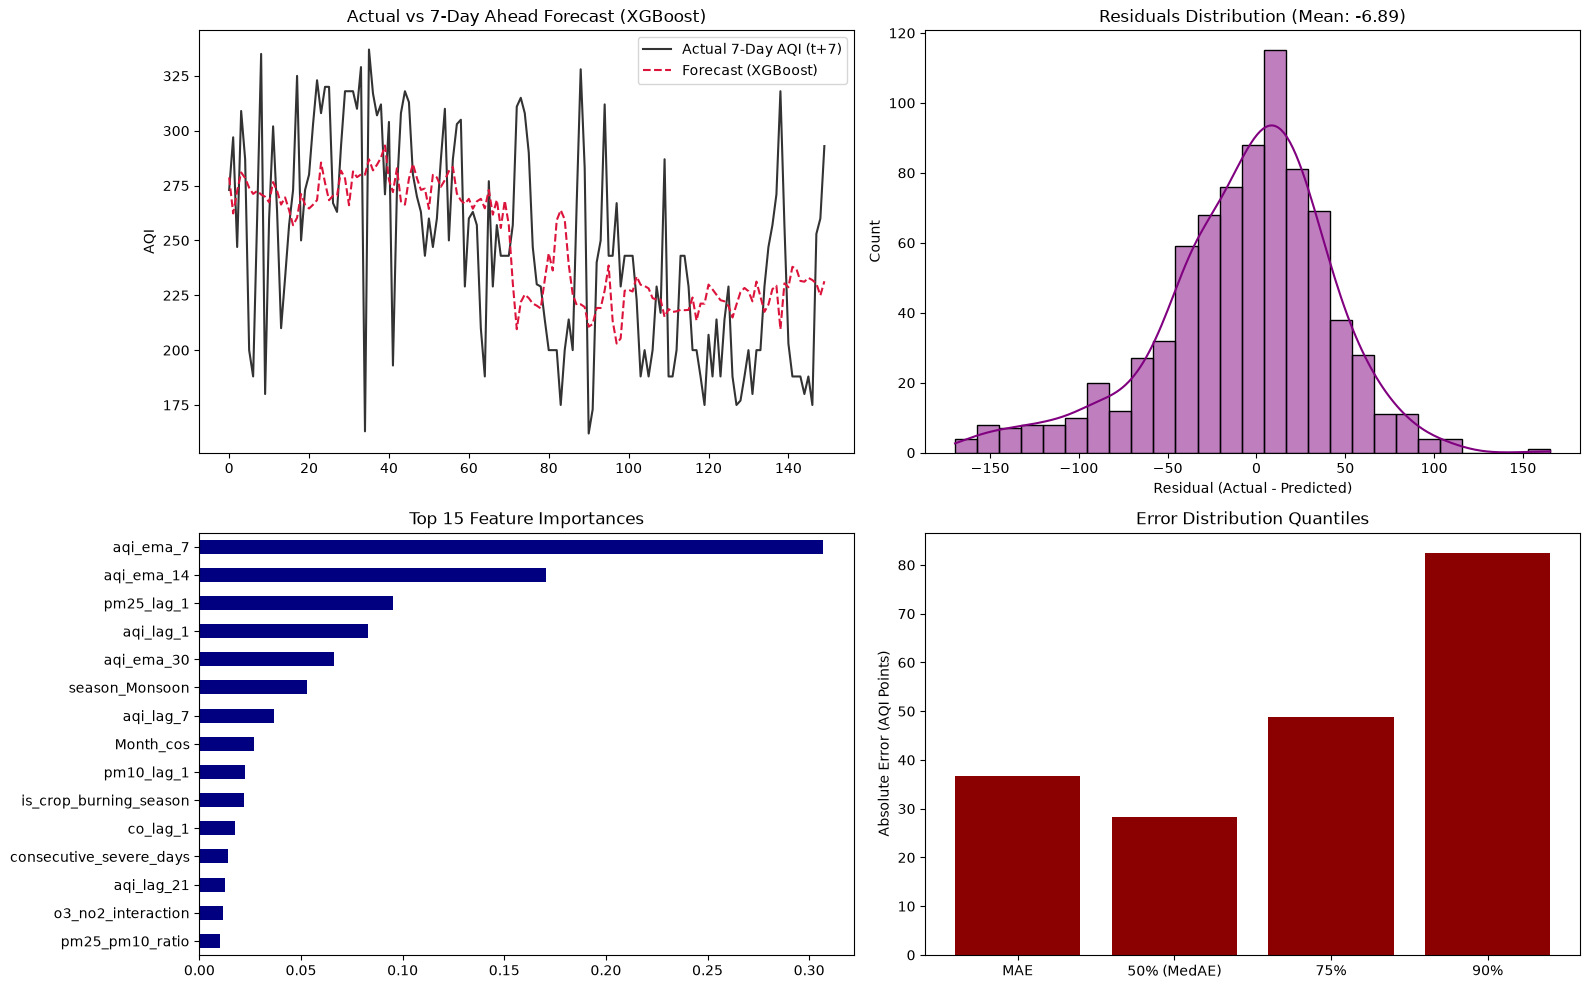

In [6]:
best_preds = best_model.predict(X_test)
residuals = y_test - best_preds

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Actual vs Forecast
axes[0, 0].plot(y_test.values[:150], label='Actual 7-Day AQI (t+7)', color='black', alpha=0.8)
axes[0, 0].plot(best_preds[:150], label=f'Forecast ({best_name})', color='crimson', linestyle='--')
axes[0, 0].set_title(f'Actual vs 7-Day Ahead Forecast ({best_name})')
axes[0, 0].legend()
axes[0, 0].set_ylabel('AQI')

# 2. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[0, 1], color='purple')
axes[0, 1].set_title(f'Residuals Distribution (Mean: {residuals.mean():.2f})')
axes[0, 1].set_xlabel('Residual (Actual - Predicted)')

# 3. Feature Importances
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=selected_features).sort_values(ascending=False).head(15)
    importances.plot(kind='barh', ax=axes[1, 0], color='navy')
    axes[1, 0].set_title('Top 15 Feature Importances')
    axes[1, 0].invert_yaxis()

# 4. Error Quantiles
stats_res = pd.Series(np.abs(residuals)).describe()
axes[1, 1].bar(['MAE', '50% (MedAE)', '75%', '90%'], [results[best_name]['MAE'], stats_res['50%'], stats_res['75%'], np.percentile(np.abs(residuals), 90)], color='darkred')
axes[1, 1].set_title('Error Distribution Quantiles')
axes[1, 1].set_ylabel('Absolute Error (AQI Points)')

plt.tight_layout()
plt.show()

In [7]:
models_dir = '../models/daily' if os.path.exists('../models') else 'models/daily'
os.makedirs(models_dir, exist_ok=True)

joblib.dump(best_model, os.path.join(models_dir, 'model.pkl'))
joblib.dump(scaler, os.path.join(models_dir, 'scaler.pkl'))
joblib.dump(selected_features, os.path.join(models_dir, 'feature_columns.pkl'))

metadata = {
    'best_model_name': best_name,
    'target': 'AQI.shift(-7)',
    'features': selected_features,
    'metrics': results[best_name],
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'project_version': '3.2.0-recovered-optimal-7day-forecaster'
}

with open(os.path.join(models_dir, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

print(f'✓ Successfully serialized {best_name} 7-day forecaster to {models_dir}/.')

✓ Successfully serialized XGBoost 7-day forecaster to ../models/daily/.
